# VeloxChem: Automated Workflow for Polarizable and Electrostatic QM/MM environments

## 1. Introduction

We present an easy-to-use, end-to-end workflow in VeloxChem for:
- Parsing molecular ensembles (single structures or trajectories) 
- Running QM/MM-style calculations. 
- Including both polarizable (PE) and non-polarizable (NPE), i.e. electrostatic environment models
- Optional excited-state calculations and averaged UV/Vis spectra generation.

## 2. Applications

- Complex light-sensitive membrane-protein systems, e.g., Channelrhodopsin-2 [1]

## 3. Initialization

### 3.1. Single Structure

**Input Structures:**
- Single PDB (multiple structures)
- Single PDB (one structure)


### 3.2. Trajectory

- Time-resolved trajectory (e.g.,`.xtc` + `.tpr`)
- `num_snapshots`: Controls snapshot extraction.
    - _Default_: All snapshots used.
    - _If provided_: Snapshots selected evenly spaced.
- `start`: Trajectory window start time (ps). _Default_: First snapshot time.
- `end`: Trajectory window end time (ps). _Default_: Last snapshot time.
- `last_snapshot_only = True`: Processes only the final snapshot.


In [1]:
import veloxchem as vlx

ens_parser = vlx.EnsembleParser()

ensemble = ens_parser.structures(
    trajectory_file = "alpha-helix-acetone-water.xtc",
    topology_file = "alpha-helix-acetone-water.tpr",
    qm_region = 'resname LIG',
    num_snapshots = 2,
    pe_cutoff = 2.5,
    npe_cutoff = 5.0,
)

/home/rocky/.conda/envs/vlxenv_ens_3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
print("number residues PE = ", ensemble[0]["number_residues_pe"])
print("number residues NPE = ", ensemble[0]["number_residues_npe"])

number residues PE =  5
number residues NPE =  18


**Key Parameters**:
- `qm_region`: MDAnalysis selection string (defines QM region).
- `qm_charge`: specifies the charge of the QM region
- `env_region`: MDAnalysis selection string (defines environment). If `env_region` is not defined, the entire system is treated as QM.
    - _Default_: All atoms not in qm_region.

## 4. Polarizable / Electrostatic  models

![image info](./models.png)

In [3]:
ens_drv = vlx.EnsembleDriver()

ens_drv.set_env_models(
    pe_model=["CP3", "SEP"],
    npe_model=["ff19sb", "tip3p"],
)

## 5. Automatic SCF and spectrum calculations

In [4]:
scf_options = {
   "scf_type": "restricted",
   "conv_thresh": 1.0e-6,
   "max_iter": 150,
   "xcfun": "CAM-B3LYP",
   "grid_level": 4,
}

property_options = {
    "property": "absorption",
    "nstates": 3,
    "nto": True,
}

In [5]:
results = ens_drv.compute(
   ensemble,
   basis_set = "6-31G",
   scf_options = scf_options,
   property_options = property_options,
)

                                                                                                                          
                                            Self Consistent Field Driver Setup                                            
                                                                                                                          
                   Wave Function Model             : Spin-Restricted Kohn-Sham with PE                                    
                   Initial Guess Model             : Superposition of Atomic Densities                                    
                   Convergence Accelerator         : Two Level Direct Inversion of Iterative Subspace                     
                   Max. Number of Iterations       : 150                                                                  
                   Max. Number of Error Vectors    : 10                                                                   
                

## 6. Averaged UV/Vis spectra

<Axes: title={'center': 'Absorption Spectrum (Averaged)'}, xlabel='Wavelength [nm]', ylabel='$\\epsilon$ [L mol$^{-1}$ cm$^{-1}$]'>

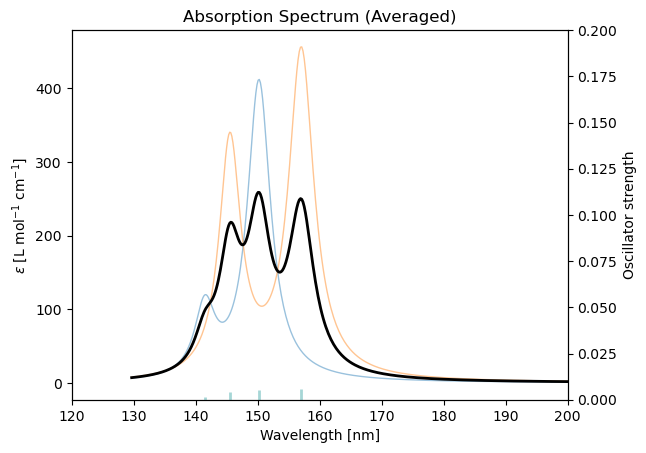

In [7]:
ens_drv.plot_uv_vis_spectra(
    results,
    show_individual = True,
    show_sticks = True,
    xlim_nm = (120,200)
)

**Averaged spectra options:**
- `show_individual`: displays each snapshot-spectra.
  - _Default_: True.
- `show_bars`: displays oscillator strengths.
  - _Default_: True.
- `xlim_nm`: Option to trim the spectra for improved clarity.

**References**

[1] Carrasco-Busturia, D et al. J. Chem. Theory Comput. 2026, 22, 1133−1148.

[2] Reinholdt, P. et al. J. Chem. Theory Comput. 2020, 16, 1162−1174.

[3] Tian, C. et al. J. Chem. Theory Comput. 2020, 16, 528−552.

[4] Beerepoot, M. T. P. et al. J. Chem. Theory Comput. 2016, 12, 1684−1695.

[5] Jorgensen, W. L. et al. J Chem Phys, 79, 926 (1983).
